In [1]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn -q

# Model Deteksi Spam SMS dengan TF-IDF dan Regresi Logistik
*Notebook* ini akan memandu proses pembangunan model *machine learning* klasik untuk mengklasifikasikan pesan SMS sebagai "spam" atau "ham" (bukan spam).

## Penjelasan Dataset yang digunakan

### 1. Kasus yang diambil
Kasus yang diangkat adalah **Deteksi Spam SMS**, sebuah tugas klasifikasi biner. Tujuannya adalah untuk melatih model yang dapat secara akurat membedakan antara SMS yang sah (ham) dan SMS yang tidak diinginkan (spam) berdasarkan konten teksnya.

### 2. Penjelasan setiap kolomnya
Kita menggunakan dataset publik "SMS Spam Collection" dari UCI, yang tersedia di Kaggle sebagai `spam.csv`.

File `spam.csv` memiliki 5 kolom, namun kita hanya akan fokus pada dua kolom pertama:
* **v1**: (object) Label kategori, berisi "ham" atau "spam". Ini akan menjadi target (`y`) kita.
* **v2**: (object) Teks mentah dari pesan SMS. Ini akan menjadi fitur (`X`) kita.
* `Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`: Kolom sisa yang akan kita buang.

In [31]:
# 3. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

# Import NLTK (Natural Language Toolkit)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Import Scikit-learn (for Model & Vectorization)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Import for additional visualization
from wordcloud import WordCloud

# Download NLTK resources (only need to run once)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set plot style
plt.style.use('ggplot')
print("library berhasil di-import.")

library berhasil di-import.


In [32]:
# 4. Load data
try:
    # Use encoding='latin1' as this dataset doesn't use standard utf-8
    df_raw = pd.read_csv("spam.csv", encoding='latin1')
    print("File spam.csv berhasil dimuat.")

    # Select only the columns we need
    df = df_raw[['v1', 'v2']]

    # Rename columns to be more readable
    df = df.rename(columns={'v1': 'label_text', 'v2': 'text'})

    # Display the first 5 rows
    display(df.head())

except Exception as e:
    print(f"Error saat memuat data: {e}")

File spam.csv berhasil dimuat.


,label_text,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data Understanding
Di bagian ini, kita akan melakukan:
1.  **Labeling Data:** Mengubah label "ham"/"spam" menjadi 0/1 (ini ada di template asli sebagai bagian dari "Data Text Processing", tapi lebih pas di sini).
2.  **Cleaning:** Memeriksa dan menangani data kosong dan duplikat.
3.  **Analisis:** Memeriksa jumlah baris, panjang teks, dan distribusi kelas.

In [35]:
# Labeling data (from Data Text Processing template)
df['label'] = df['label_text'].map({'ham': 0, 'spam': 1})

# Check for null/empty data
print(f"Data kosong (NaN) sebelum dihapus:\n{df.isnull().sum()}")
df = df.dropna()

# Check for duplicate data
duplicates = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Baris duplikat dihapus. Jumlah baris baru: {len(df)}")

print("\n--- Info Dataset Setelah Cleaning ---")
# Number of data rows
df.info()

# Average length of each row
df['text_length'] = df['text'].apply(len)
print(f"\nPanjang rata-rata SMS: {df['text_length'].mean():.2f} karakter")

Data kosong (NaN) sebelum dihapus:
label_text     0
text           0
label          0
text_length    0
dtype: int64

Jumlah baris duplikat: 0

--- Info Dataset Setelah Cleaning ---
<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label_text   5169 non-null   object
 1   text         5169 non-null   object
 2   label        5169 non-null   int64 
 3   text_length  5169 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 201.9+ KB

Panjang rata-rata SMS: 78.98 karakter



--- Distribusi Kelas (Label) ---
label
0    0.87367
1    0.12633
Name: proportion, dtype: float64


/tmp/ipython-input-2440137157.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='pastel')


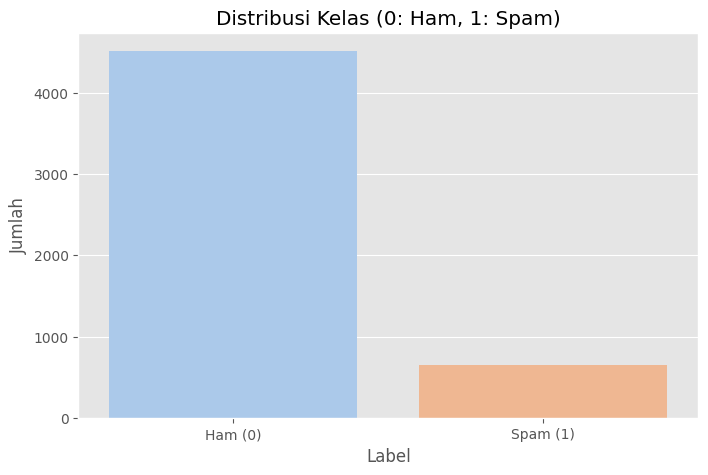

In [34]:
# 5. Data distribution (bar chart)
print("\n--- Distribusi Kelas (Label) ---")
print(df['label'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='pastel')
plt.title('Distribusi Kelas (0: Ham, 1: Spam)')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.ylabel('Jumlah')
plt.xlabel('Label')
plt.show()

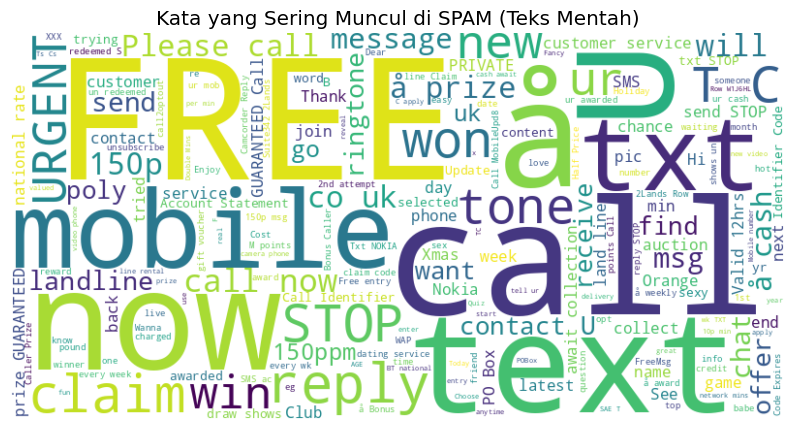

In [39]:
# 5. Data distribution (Word Cloud Spam)
spam_text = " ".join(df[df['label'] == 1]['text'])
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Kata yang Sering Muncul di SPAM (Teks Mentah)')
plt.axis('off')
plt.show()

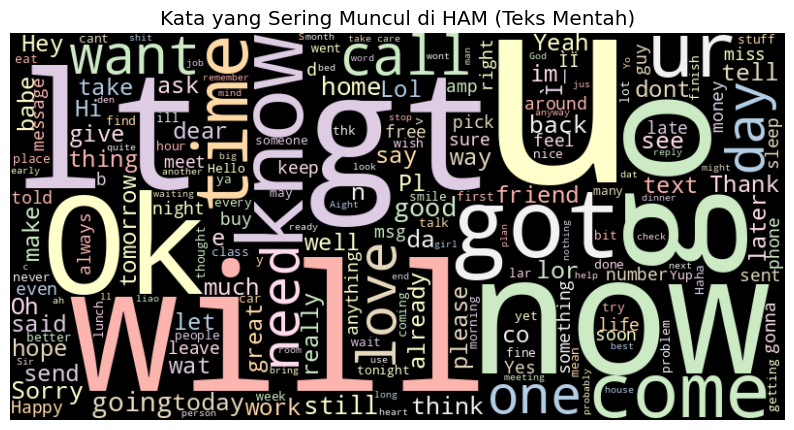

In [40]:
# 5. Data distribution (Word Cloud Ham)
ham_text = " ".join(df[df['label'] == 0]['text'])
wordcloud_ham = WordCloud(width=800, height=400, background_color='black', colormap='Pastel1').generate(ham_text)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Kata yang Sering Muncul di HAM (Teks Mentah)')
plt.axis('off')
plt.show()

## Data Text Processing
Kita akan membersihkan teks mentah, mengubahnya menjadi vektor angka (vektorisasi), dan membagi data.

In [42]:
# Preprocessing Function (Tokenization, Stopword, Lemmatization, Normalization)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Text Normalization (lowercase)
    text = str(text).lower()

    # Stopword removal (URLs, emails, punctuation, numbers)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', ' ', text)

    # Tokenization
    tokens = word_tokenize(text)

    cleaned_tokens = []
    for word in tokens:
        # Stopword removal (words)
        if word not in stop_words and len(word) > 1:
            # Lemmatization (Stemming is not used)
            cleaned_tokens.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_tokens)

# Apply the preprocessing function
print("Memulai preprocessing teks...")
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Preprocessing teks selesai.")
display(df[['text', 'cleaned_text']].head())

Memulai preprocessing teks...
Preprocessing teks selesai.


,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [44]:
# Data splitting with scale (0.8, 0.2)

# Define X and y from the cleaned columns
X = df['cleaned_text']
y = df['label']

# We split the data BEFORE vectorization
# stratify=y is very important for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah data Latih (Train): {X_train.shape[0]}")
print(f"Jumlah data Tes (Test): {X_test.shape[0]}")

Jumlah data Latih (Train): 4135
Jumlah data Tes (Test): 1034


In [45]:
# 8. Text Vectorization (TF-IDF)
# We will limit features/words to the 5000 most common
VOCAB_SIZE_LIMIT = 5000

tfidf_vectorizer = TfidfVectorizer(
    max_features=VOCAB_SIZE_LIMIT,
    max_df=0.9, # Ignore words that are too common (in >90% of docs)
    min_df=2    # Ignore words that are too rare (appear only once)
)

# Learn the vocabulary ONLY from the training data (X_train)
print("Fitting TF-IDF vectorizer...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data using the same vocabulary
print("Transforming test data...")
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape matriks TF-IDF data latih: {X_train_tfidf.shape}")

Fitting TF-IDF vectorizer...
Transforming test data...
Shape matriks TF-IDF data latih: (4135, 2739)


## Data Modeling

### Penjelasan tentang model yang dipilih
Kita akan menggunakan **Regresi Logistik (Logistic Regression)**. Ini adalah model *machine learning* klasik yang sangat cepat, efisien, dan stabil untuk klasifikasi teks.

Kita menggunakan **TF-IDF** untuk vektorisasi, yang memberi bobot pada kata-kata berdasarkan seberapa penting kata tersebut.

Kita juga menggunakan `class_weight='balanced'` karena dataset kita tidak seimbang (86% Ham, 14% Spam). Ini akan "menghukum" model lebih berat jika salah mengklasifikasikan "Spam", sehingga model menjadi lebih waspada.

In [46]:
# Model Training
print("Mulai pelatihan model Regresi Logistik...")

# Initialize the model
model_lr = LogisticRegression(
    class_weight='balanced', # Important for imbalanced data
    max_iter=1000,
    random_state=42
)

# Train the model
model_lr.fit(X_train_tfidf, y_train)

print("--- Pelatihan Model Selesai ---")

Mulai pelatihan model Regresi Logistik...
--- Pelatihan Model Selesai ---


## Data Evaluasi
Kita akan mengevaluasi model menggunakan data tes yang belum pernah dilihat sebelumnya.


--- Evaluasi pada Data Tes ---
Akurasi Tes: 97.78%

--- Laporan Klasifikasi (Data Tes) ---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99       903
    Spam (1)       0.90      0.92      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034


--- Confusion Matrix (Data Tes) ---


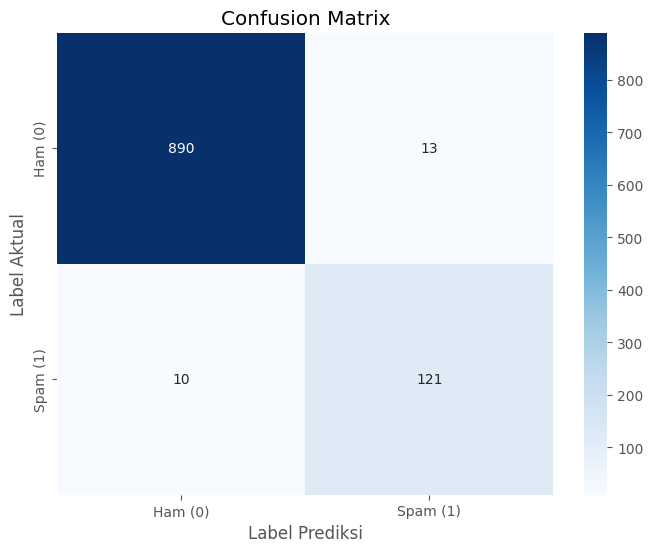

In [47]:
# Confusion Matrix & Classification Report
print("\n--- Evaluasi pada Data Tes ---")

# Predict on the test data (X_test_tfidf)
y_pred = model_lr.predict(X_test_tfidf)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Tes: {test_accuracy*100:.2f}%")

# Classification Report (Test Data)
print("\n--- Laporan Klasifikasi (Data Tes) ---")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

# Confusion Matrix (Test Data)
print("\n--- Confusion Matrix (Data Tes) ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (0)', 'Spam (1)'],
            yticklabels=['Ham (0)', 'Spam (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()

## Data Prediksi
Ini adalah ujian akhir: menggunakan model yang sudah dilatih untuk memprediksi data baru yang belum pernah dilihat sebelumnya.

In [48]:
# Use the trained model and predict on new data
new_data = [
    # 1. Spam (expected: Spam)
    "Congratulations! You've won a $1,000 Amazon gift card. Click here to claim your prize now!",

    # 2. Ham (expected: Ham)
    "Hi team, just a reminder about our weekly meeting tomorrow at 10 AM. Please review the agenda attached.",

    # 3. Spam (expected: Spam)
    "URGENT: Your account has been suspended due to suspicious activity. Please click this link to verify your identity immediately.",

    # 4. Ham (expected: Ham)
    "Thanks for your order #12345! Your package has been shipped and will arrive in 3-5 business days."
]

# 1. Clean the new data
processed_data = [preprocess_text(text) for text in new_data]

# 2. Vectorize the new data
new_tfidf = tfidf_vectorizer.transform(processed_data)

# 3. Predict
print("\n--- Membuat Prediksi Baru ---")
predictions = model_lr.predict(new_tfidf)
predictions_proba = model_lr.predict_proba(new_tfidf)

# 4. Display results
for i in range(len(new_data)):
    print(f"\nSMS: {new_data[i]}")
    pred_label = "Spam (1)" if predictions[i] == 1 else "Ham (0)"
    confidence = predictions_proba[i, predictions[i]] # Confidence in the predicted label

    print(f"Prediksi: {pred_label} (Keyakinan: {confidence:.4f})")


--- Membuat Prediksi Baru ---

SMS: Congratulations! You've won a $1,000 Amazon gift card. Click here to claim your prize now!
Prediksi: Spam (1) (Keyakinan: 0.8266)

SMS: Hi team, just a reminder about our weekly meeting tomorrow at 10 AM. Please review the agenda attached.
Prediksi: Ham (0) (Keyakinan: 0.7059)

SMS: URGENT: Your account has been suspended due to suspicious activity. Please click this link to verify your identity immediately.
Prediksi: Spam (1) (Keyakinan: 0.6559)

SMS: Thanks for your order #12345! Your package has been shipped and will arrive in 3-5 business days.
Prediksi: Ham (0) (Keyakinan: 0.6930)
